# 01 — Подготовка данных для моделей

Цель ноутбука: **один раз подготовить данные** и сохранить одинаковые train/test-наборы, чтобы потом отдельные ноутбуки с моделями обучались на одних и тех же данных.

Будущая структура:

```text
notebooks/
  01_data_preprocessing.ipynb
  02_decision_tree.ipynb
  03_random_forest.ipynb
  04_catboost.ipynb

data/
  processed/
    2023/
    2024/
    2025/
  modeling/
    moscow_modeling_full.csv
    moscow_train.csv
    moscow_test.csv
    feature_columns.json
    target_column.json
```

## 1. Импорт библиотек

In [1]:
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## 2. Настройки проекта

Тут задаём путь к исходным CSV, целевую колонку и список признаков, которые реально есть в данных.

In [2]:
DATA_PATTERN = "../data/processed/202*/moscow_202*.csv"

TARGET = "Price"

SELECTED_COLUMNS = [
    "Price",
    "Apartment type",
    "Metro station",
    "Minutes to metro",
    "Number of rooms",
    "Area",
    "Living area",
    "Kitchen area",
    "Floor",
    "Number of floors",
    "Renovation",
]

FEATURES = [col for col in SELECTED_COLUMNS if col != TARGET]

OUTPUT_DIR = Path("../data/modeling")
REPORTS_DIR = Path("../reports")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Target:", TARGET)
print("Features:")
for col in FEATURES:
    print("-", col)

Target: Price
Features:
- Apartment type
- Metro station
- Minutes to metro
- Number of rooms
- Area
- Living area
- Kitchen area
- Floor
- Number of floors
- Renovation


## 3. Поиск исходных файлов

In [3]:
files = sorted(glob.glob(DATA_PATTERN))

print("Найдено файлов:", len(files))
for file in files:
    print(file)

if not files:
    raise FileNotFoundError(
        f"Файлы не найдены по шаблону {DATA_PATTERN}. "
        "Проверь, где лежит ноутбук относительно папки data."
    )

Найдено файлов: 4
../data/processed/2023/moscow_2023.csv
../data/processed/2024/moscow_2024.csv
../data/processed/2025/moscow_2025.csv
../data/processed/2026/moscow_2026.csv


## 4. Загрузка и объединение CSV

Добавляем служебную колонку `source_file`, чтобы понимать, из какого файла пришла строка.

In [4]:
dfs = []

for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = file
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True)

print("Размер исходной таблицы:", df_raw.shape)
df_raw.head()

Размер исходной таблицы: (23508, 29)


,Price,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,...,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link,Region,district,street,registration_quarter
0,108800000.0,Secondary,Чеховская,5.0,3.0,108.8,57.1,15.6,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,53000000.0,Secondary,Арбатская,9.0,3.0,96.9,59.0,11.1,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,44240000.0,Secondary,Фили,6.0,3.0,63.2,34.1,11.9,40.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,105000000.0,Secondary,Белорусская,6.0,3.0,145.0,75.4,18.6,3.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,47000000.0,Secondary,Белорусская,9.0,3.0,103.8,59.0,15.0,6.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Проверка нужных колонок

Если какой-то колонки нет, ноутбук покажет это явно.

In [5]:
available_columns = df_raw.columns.tolist()

missing_selected_columns = [col for col in SELECTED_COLUMNS if col not in available_columns]
existing_selected_columns = [col for col in SELECTED_COLUMNS if col in available_columns]

print("Нужные колонки, которые есть:", existing_selected_columns)
print("Нужные колонки, которых нет:", missing_selected_columns)

if TARGET not in df_raw.columns:
    raise ValueError(f"Целевая колонка {TARGET} не найдена. Доступные колонки: {available_columns}")

Нужные колонки, которые есть: ['Price', 'Apartment type', 'Metro station', 'Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Renovation']
Нужные колонки, которых нет: []


## 6. Оставляем только нужные колонки

Для моделирования сейчас используем только выбранные признаки и цену. Остальные колонки не тащим дальше.

In [6]:
df = df_raw[existing_selected_columns + ["source_file"]].copy()

print("Размер после выбора колонок:", df.shape)
df.head()

Размер после выбора колонок: (23508, 12)


,Price,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,source_file
0,108800000.0,Secondary,Чеховская,5.0,3.0,108.8,57.1,15.6,3.0,3.0,Without renovation,../data/processed/2023/moscow_2023.csv
1,53000000.0,Secondary,Арбатская,9.0,3.0,96.9,59.0,11.1,2.0,5.0,Without renovation,../data/processed/2023/moscow_2023.csv
2,44240000.0,Secondary,Фили,6.0,3.0,63.2,34.1,11.9,40.0,41.0,Designer,../data/processed/2023/moscow_2023.csv
3,105000000.0,Secondary,Белорусская,6.0,3.0,145.0,75.4,18.6,3.0,6.0,Designer,../data/processed/2023/moscow_2023.csv
4,47000000.0,Secondary,Белорусская,9.0,3.0,103.8,59.0,15.0,6.0,6.0,Without renovation,../data/processed/2023/moscow_2023.csv


## 7. Очистка цены

Цена может быть числом или строкой. Приводим её к `float`.

In [7]:
def clean_price(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    value = str(value)
    value = value.replace("₽", "")
    value = value.replace("руб.", "")
    value = value.replace("руб", "")
    value = value.replace(" ", "")
    value = value.replace(",", ".")

    cleaned = "".join(ch for ch in value if ch.isdigit() or ch == ".")

    if cleaned == "":
        return np.nan

    return float(cleaned)


df[TARGET] = df[TARGET].apply(clean_price)

df[TARGET].describe()

count    1.654700e+04
mean     4.718555e+07
std      9.465559e+07
min      1.150000e+06
25%      1.000000e+07
50%      1.580000e+07
75%      3.950000e+07
max      2.455020e+09
Name: Price, dtype: float64

## 8. Удаляем строки без цены

Без целевой переменной модель не сможет учиться.

In [8]:
before = len(df)

df = df.dropna(subset=[TARGET]).copy()

after = len(df)

print("Было строк:", before)
print("Стало строк:", after)
print("Удалили строк без цены:", before - after)

Было строк: 23508
Стало строк: 16547
Удалили строк без цены: 6961


## 9. График распределения цены до удаления выбросов

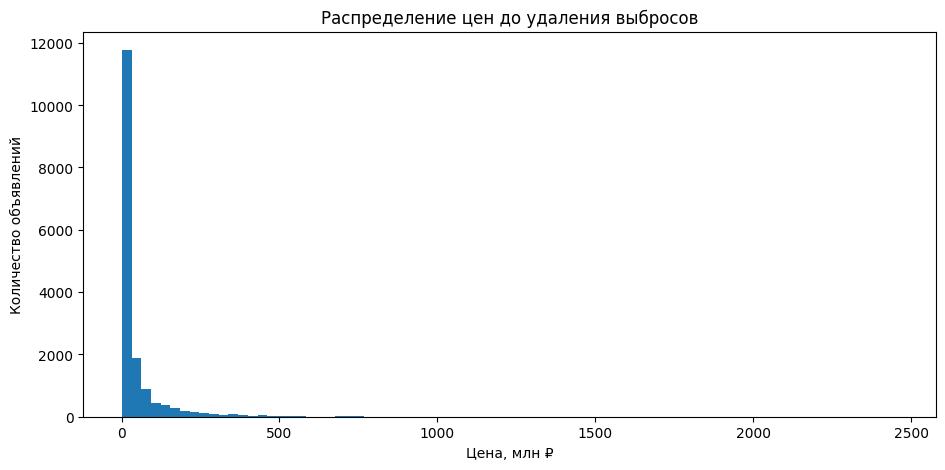

In [9]:
ax = (df[TARGET] / 1_000_000).plot(
    kind="hist",
    bins=80,
    figsize=(11, 5),
    title="Распределение цен до удаления выбросов"
)

ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Количество объявлений")
plt.show()

## 10. Логарифм цены

Логарифм делает распределение цен недвижимости более читаемым.

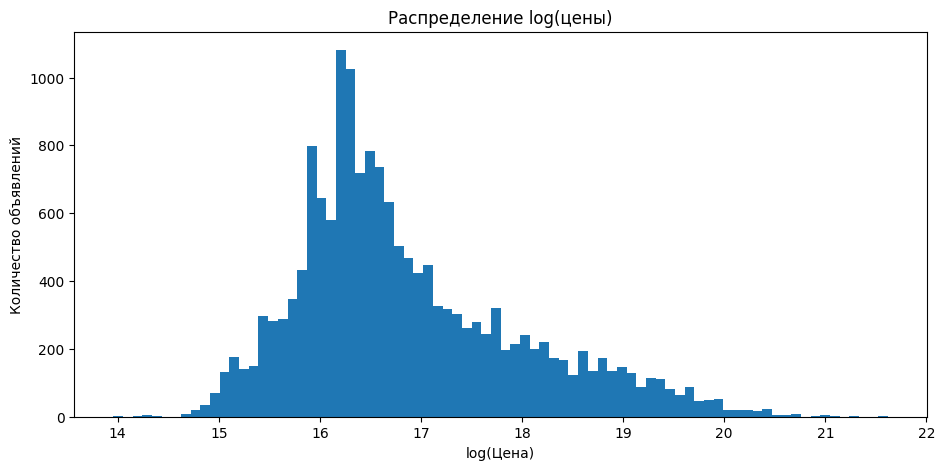

In [10]:
ax = np.log1p(df[TARGET]).plot(
    kind="hist",
    bins=80,
    figsize=(11, 5),
    title="Распределение log(цены)"
)

ax.set_xlabel("log(Цена)")
ax.set_ylabel("Количество объявлений")
plt.show()

## 11. Удаление крайних выбросов по цене

Для первого сравнения моделей убираем 1% самых дешёвых и 1% самых дорогих объявлений.

In [ ]:
low_price = df[TARGET].quantile(0.03)
high_price = df[TARGET].quantile(0.97)

print("1% квантиль:", f"{low_price:,.0f}".replace(",", " "), "₽")
print("99% квантиль:", f"{high_price:,.0f}".replace(",", " "), "₽")

before = len(df)

df_model = df[
    (df[TARGET] >= low_price) &
    (df[TARGET] <= high_price)
].copy()

after = len(df_model)

print("Было строк:", before)
print("Стало строк:", after)
print("Удалили выбросов:", before - after)

df_model[TARGET].describe()

1% квантиль: 3 363 800 ₽
99% квантиль: 450 000 000 ₽
Было строк: 16547
Стало строк: 16228
Удалили выбросов: 319


count    1.622800e+04
mean     4.147156e+07
std      6.570324e+07
min      3.380000e+06
25%      1.013506e+07
50%      1.580000e+07
75%      3.800000e+07
max      4.500000e+08
Name: Price, dtype: float64

## 12. График распределения цены после удаления выбросов

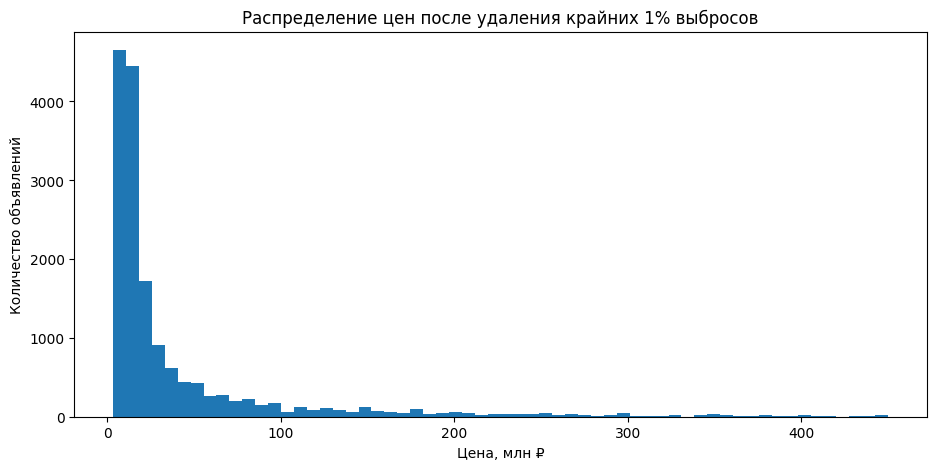

In [12]:
ax = (df_model[TARGET] / 1_000_000).plot(
    kind="hist",
    bins=60,
    figsize=(11, 5),
    title="Распределение цен после удаления крайних 1% выбросов"
)

ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Количество объявлений")
plt.show()

## 13. Boxplot цены после удаления выбросов

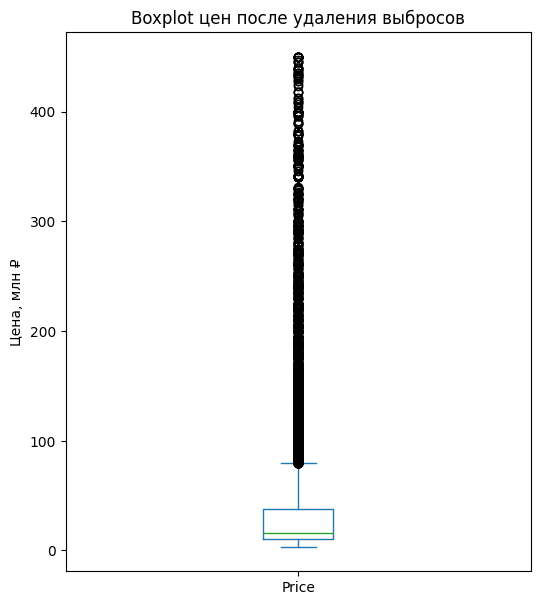

In [13]:
ax = (df_model[TARGET] / 1_000_000).plot(
    kind="box",
    figsize=(6, 7),
    title="Boxplot цен после удаления выбросов"
)

ax.set_ylabel("Цена, млн ₽")
plt.show()

## 14. Пропуски в выбранных признаках

Мы сохраняем признаки с пропусками. Заполнение пропусков будет происходить в ноутбуках моделей через `SimpleImputer` или через встроенную обработку модели.

In [14]:
current_features = [col for col in FEATURES if col in df_model.columns]

missing_features = (
    df_model[current_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_share")
)

missing_features

,missing_share
Floor,0.022985
Number of floors,0.022985
Minutes to metro,0.002034
Metro station,0.002034
Apartment type,0.000000
Number of rooms,0.000000
Living area,0.000000
Area,0.000000
Kitchen area,0.000000
Renovation,0.000000


## 15. Красивый график пропусков

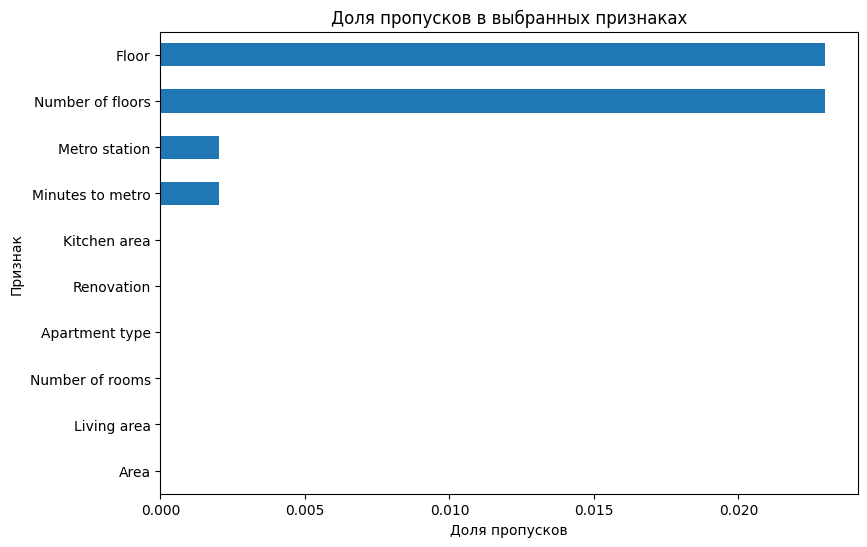

In [15]:
ax = missing_features.sort_values("missing_share").plot(
    kind="barh",
    figsize=(9, 6),
    title="Доля пропусков в выбранных признаках",
    legend=False
)

ax.set_xlabel("Доля пропусков")
ax.set_ylabel("Признак")
plt.show()

## 16. Типы выбранных признаков

Это пригодится в модельных ноутбуках: числовые признаки будем заполнять медианой, категориальные — самым частым значением.

In [16]:
X_preview = df_model[current_features].copy()

numeric_features = X_preview.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_preview.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['Minutes to metro', 'Number of rooms', 'Area', 'Living area', 'Kitchen area', 'Floor', 'Number of floors']

Категориальные признаки:
['Apartment type', 'Metro station', 'Renovation']


/tmp/ipykernel_64757/3517453542.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_preview.select_dtypes(


## 17. Сохраняем список признаков и target

Это важно: все модели будут брать один и тот же список признаков.

In [17]:
feature_columns_path = OUTPUT_DIR / "feature_columns.json"
target_column_path = OUTPUT_DIR / "target_column.json"
numeric_features_path = OUTPUT_DIR / "numeric_features.json"
categorical_features_path = OUTPUT_DIR / "categorical_features.json"

with open(feature_columns_path, "w", encoding="utf-8") as f:
    json.dump(current_features, f, ensure_ascii=False, indent=2)

with open(target_column_path, "w", encoding="utf-8") as f:
    json.dump({"target": TARGET}, f, ensure_ascii=False, indent=2)

with open(numeric_features_path, "w", encoding="utf-8") as f:
    json.dump(numeric_features, f, ensure_ascii=False, indent=2)

with open(categorical_features_path, "w", encoding="utf-8") as f:
    json.dump(categorical_features, f, ensure_ascii=False, indent=2)

print("Список признаков сохранён:", feature_columns_path)
print("Target сохранён:", target_column_path)
print("Числовые признаки сохранены:", numeric_features_path)
print("Категориальные признаки сохранены:", categorical_features_path)

Список признаков сохранён: ../data/modeling/feature_columns.json
Target сохранён: ../data/modeling/target_column.json
Числовые признаки сохранены: ../data/modeling/numeric_features.json
Категориальные признаки сохранены: ../data/modeling/categorical_features.json


## 18. Train/test split

Разделение тоже фиксируем здесь, чтобы все модели сравнивались честно на одном и том же test-наборе.

In [18]:
X = df_model[current_features].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12982, 10)
X_test: (3246, 10)
y_train: (12982,)
y_test: (3246,)


## 19. Собираем train/test таблицы

В файлах `moscow_train.csv` и `moscow_test.csv` будут и признаки, и целевая колонка `Price`.

In [19]:
train_df = X_train.copy()
train_df[TARGET] = y_train

test_df = X_test.copy()
test_df[TARGET] = y_test

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

train_df.head()

train_df: (12982, 11)
test_df: (3246, 11)


,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,Price
6330,Secondary,Бульвар Рокоссовского,13.0,2.0,38.0,27.0,5.0,4.0,9.0,Cosmetic,13380000.0
11955,Secondary,Новаторская,10.0,0.0,171.0,52.0,15.0,23.0,32.0,Without renovation,65000000.0
769,Secondary,Ботанический сад,4.0,0.0,25.3,14.9,8.7,5.0,18.0,Without renovation,6560000.0
9799,Secondary,Мнёвники,20.0,4.0,227.0,180.0,20.0,1.0,3.0,Designer,358820000.0
6412,Secondary,ЗИЛ,12.0,2.0,60.6,32.8,11.7,28.0,40.0,European-style renovation,27776000.0


## 20. Сохраняем итоговые файлы для моделей

In [20]:
full_path = OUTPUT_DIR / "moscow_modeling_full.csv"
train_path = OUTPUT_DIR / "moscow_train.csv"
test_path = OUTPUT_DIR / "moscow_test.csv"

df_model[current_features + [TARGET]].to_csv(full_path, index=False)
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Полный датасет сохранён:", full_path)
print("Train сохранён:", train_path)
print("Test сохранён:", test_path)

Полный датасет сохранён: ../data/modeling/moscow_modeling_full.csv
Train сохранён: ../data/modeling/moscow_train.csv
Test сохранён: ../data/modeling/moscow_test.csv


## 21. Итоговая сводка

In [21]:
summary = pd.DataFrame(
    {
        "item": [
            "rows_full",
            "rows_train",
            "rows_test",
            "features_count",
            "target",
            "price_min",
            "price_median",
            "price_mean",
            "price_max",
        ],
        "value": [
            len(df_model),
            len(train_df),
            len(test_df),
            len(current_features),
            TARGET,
            df_model[TARGET].min(),
            df_model[TARGET].median(),
            df_model[TARGET].mean(),
            df_model[TARGET].max(),
        ],
    }
)

summary

,item,value
0,rows_full,16228
1,rows_train,12982
2,rows_test,3246
3,features_count,10
4,target,Price
5,price_min,3380000.0
6,price_median,15800000.0
7,price_mean,41471555.508627
8,price_max,450000000.0


## 22. Сохраняем сводку

In [22]:
summary_path = REPORTS_DIR / "data_preprocessing_summary.csv"
missing_path = REPORTS_DIR / "selected_features_missing_share.csv"

summary.to_csv(summary_path, index=False)
missing_features.to_csv(missing_path)

print("Сводка сохранена:", summary_path)
print("Пропуски сохранены:", missing_path)

Сводка сохранена: ../reports/data_preprocessing_summary.csv
Пропуски сохранены: ../reports/selected_features_missing_share.csv


# Готово

Теперь в ноутбуках моделей не нужно заново чистить данные.

Они должны начинаться примерно так:

```python
import json
import pandas as pd

DATA_DIR = "../data/modeling"

train_df = pd.read_csv(f"{DATA_DIR}/moscow_train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/moscow_test.csv")

with open(f"{DATA_DIR}/feature_columns.json", "r", encoding="utf-8") as f:
    features = json.load(f)

with open(f"{DATA_DIR}/target_column.json", "r", encoding="utf-8") as f:
    target = json.load(f)["target"]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]
```